# qasmbench-medium

In [18]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/qasmbench-medium"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv   60.894737   260.315789
1         cirq.csv   56.421053   267.157895
2         qmap.csv   61.210526   273.947368
3       pytket.csv   79.789474   268.263158
4          eoh.csv   60.000000   265.157895
5    funsearch.csv   64.631579   269.789474
6        reevo.csv   61.894737   261.736842
7   Randsample.csv   62.105263   272.000000
8     mcts-ahd.csv   64.157895   281.842105
9   hill_climb.csv   48.473684   268.263158
10       sabre.csv   52.315789   254.947368
11     partevo.csv   63.631579   274.052632


In [19]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/qasmbench-medium/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/qasmbench-medium"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 -7.93                   2.56
      qmap                  0.52                   4.98
    pytket                 23.68                   2.96
       eoh                 -1.49                   1.83
 funsearch                  5.78                   3.51
     reevo                  1.62                   0.54
Randsample                  1.95                   4.30
  mcts-ahd                  5.09                   7.64
     sabre                -16.40                  -2.11
   partevo                  4.30                   5.01


# qasmbench-large

In [14]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/qasmbench-large"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv  336.318182   835.636364
1         cirq.csv  426.727273   919.045455
2         qmap.csv  368.636364   862.227273
3       pytket.csv  447.818182   905.545455
4          eoh.csv  389.545455   905.318182
5    funsearch.csv  371.636364   870.272727
6        reevo.csv  341.772727   843.545455
7   Randsample.csv  375.863636   884.681818
8     mcts-ahd.csv  359.090909   883.363636
9   hill_climb.csv  392.909091   897.363636
10       sabre.csv  358.545455   860.272727
11     partevo.csv  362.818182   881.500000


In [15]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/qasmbench-large/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/qasmbench-large"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 21.19                   9.08
      qmap                  8.77                   3.08
    pytket                 24.90                   7.72
       eoh                 13.66                   7.70
 funsearch                  9.50                   3.98
     reevo                  1.60                   0.94
Randsample                 10.52                   5.54
  mcts-ahd                  6.34                   5.40
hill_climb                 14.40                   6.88
     sabre                  6.20                   2.86
   partevo                  7.30                   5.20


# queko 16qbt

In [2]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file  swap_count  final_depth
0       qpilot.csv    0.000000   500.000000
1         cirq.csv  440.933333  1814.622222
2         qmap.csv  473.533333  1091.366667
3       pytket.csv  370.844444  1100.555556
4          eoh.csv  265.811111  1058.900000
5    funsearch.csv  315.033333  1096.022222
6        reevo.csv   89.333333   726.400000
7   Randsample.csv  250.188889   975.144444
8     mcts-ahd.csv  201.377778   900.900000
9   hill_climb.csv  257.366667  1032.111111
10       sabre.csv    2.600000   506.022222
11     partevo.csv  212.511111   904.466667


In [7]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                100.00                  72.45
      qmap                100.00                  54.19
    pytket                100.00                  54.57
       eoh                100.00                  52.78
 funsearch                100.00                  54.38
     reevo                100.00                  31.17
Randsample                100.00                  48.73
  mcts-ahd                100.00                  44.50
hill_climb                100.00                  51.56
     sabre                100.00                   0.41
   partevo                100.00                  44.72


# queko 54qbt

In [8]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file   swap_count  final_depth
0       qpilot.csv  2287.922222  1867.266667
1         cirq.csv  4378.911111  3576.366667
2         qmap.csv  7254.777778  2612.011111
3       pytket.csv  3852.411111  3276.800000
4          eoh.csv  3050.955556  2326.711111
5    funsearch.csv  3043.300000  2331.933333
6        reevo.csv  2330.044444  1941.166667
7   Randsample.csv  2913.944444  2252.144444
8     mcts-ahd.csv  2753.788889  2168.344444
9   hill_climb.csv  3005.166667  2290.877778
10       sabre.csv  3015.311111  2404.555556
11     partevo.csv  2791.055556  2158.633333


In [10]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 47.75                  47.79
      qmap                 68.46                  28.51
    pytket                 40.61                  43.02
       eoh                 25.01                  19.75
 funsearch                 24.82                  19.93
     reevo                  1.81                   3.81
Randsample                 21.48                  17.09
  mcts-ahd                 16.92                  13.89
hill_climb                 23.87                  18.49
     sabre                 24.12                  22.34
   partevo                 18.03                  13.50


# queko 81qbt

In [20]:
import pandas as pd
import os

directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt"
files = ["qpilot.csv", "cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]
columns_to_mean = ["swap_count", "final_depth"]

summary_data = []

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            means = df[columns_to_mean].mean().to_dict()
            means['source_file'] = file_name
            summary_data.append(means)
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

summary_df = pd.DataFrame(summary_data)
cols = ['source_file'] + columns_to_mean
summary_df = summary_df[cols]
print("\nPreview of the data:")
print(summary_df)


Preview of the data:
       source_file    swap_count  final_depth
0       qpilot.csv   6145.255556  2687.266667
1         cirq.csv   9331.511111  4085.200000
2         qmap.csv  14691.977778  3567.088889
3       pytket.csv   9999.477778  5368.911111
4          eoh.csv   7667.733333  3317.622222
5    funsearch.csv   7300.988889  3199.188889
6        reevo.csv   6283.677778  2738.900000
7   Randsample.csv   7466.811111  3235.144444
8     mcts-ahd.csv   6863.122222  2976.688889
9   hill_climb.csv   7503.255556  3245.322222
10       sabre.csv   7893.022222  3817.522222
11     partevo.csv   7106.355556  3086.022222


In [21]:
import pandas as pd
import os

llm_path = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/qpilot.csv"
try:
    df_llm = pd.read_csv(llm_path)
    llm_swaps = df_llm["swap_count"].mean()
    llm_depth = df_llm["final_depth"].mean()
except Exception as e:
    print(f"Error reading LLM file: {e}")
    exit()

baselines = {}


directory = "/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt"
files = ["cirq.csv", "qmap.csv", "pytket.csv", "eoh.csv", "funsearch.csv", "reevo.csv", "Randsample.csv", "mcts-ahd.csv", "hill_climb.csv", "sabre.csv", "partevo.csv"]

for file_name in files:
    file_path = os.path.join(directory, file_name)
    if os.path.exists(file_path):
        try:
            df = pd.read_csv(file_path)
            method_name = file_name.replace(".csv", "")
            baselines[method_name] = {
                "swaps": df["swap_count"].mean(),
                "depth": df["final_depth"].mean()
            }
        except Exception as e:
            print(f"Error processing {file_name}: {e}")
    else:
        print(f"File not found: {file_path}")

improvement_data = []

for method, metrics in baselines.items():
    base_swaps = metrics["swaps"]
    base_depth = metrics["depth"]
    
    swap_imp = ((base_swaps - llm_swaps) / base_swaps) * 100
    depth_imp = ((base_depth - llm_depth) / base_depth) * 100
    
    improvement_data.append({
        "Method": method,
        "Swap Improvement (%)": swap_imp,
        "Depth Improvement (%)": depth_imp
    })

if improvement_data:
    results_df = pd.DataFrame(improvement_data)
    print(results_df.to_string(index=False, float_format="%.2f"))    
else:
    print("No baseline data was processed.")

    Method  Swap Improvement (%)  Depth Improvement (%)
      cirq                 34.15                  34.22
      qmap                 58.17                  24.66
    pytket                 38.54                  49.95
       eoh                 19.86                  19.00
 funsearch                 15.83                  16.00
     reevo                  2.20                   1.89
Randsample                 17.70                  16.94
  mcts-ahd                 10.46                   9.72
hill_climb                 18.10                  17.20
     sabre                 22.14                  29.61
   partevo                 13.52                  12.92


# plots

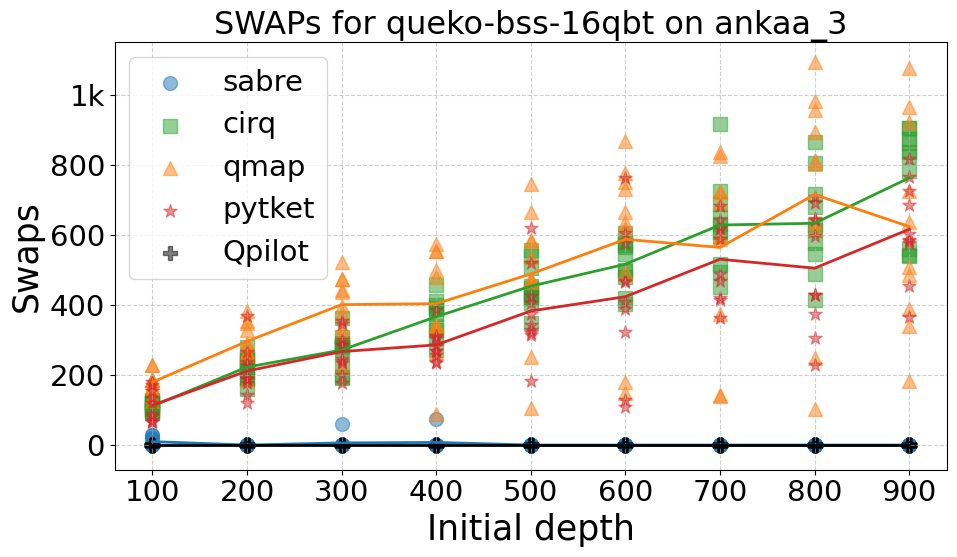

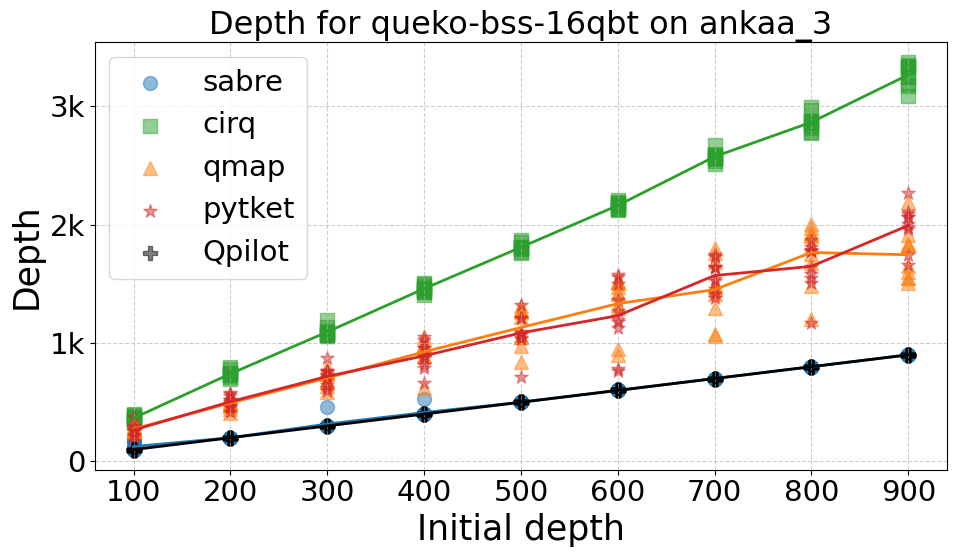

In [18]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

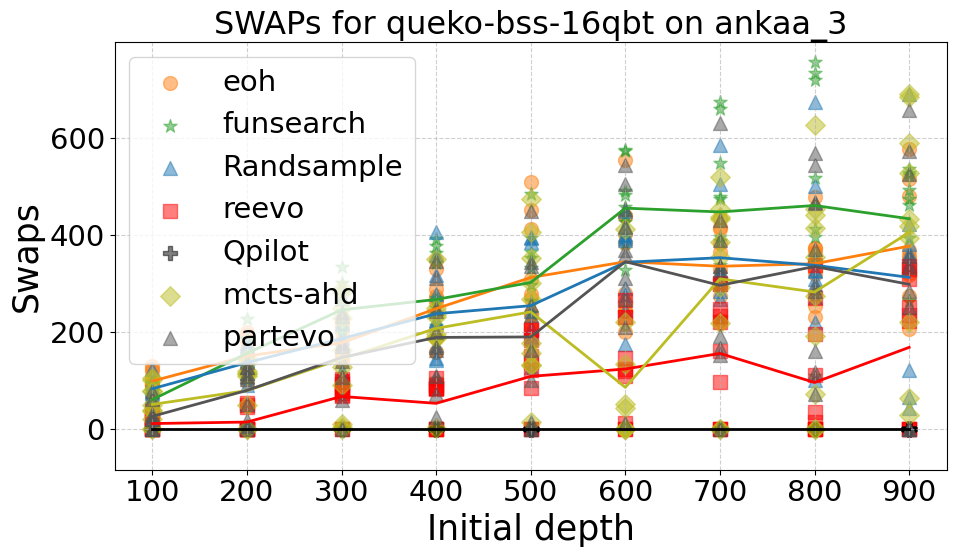

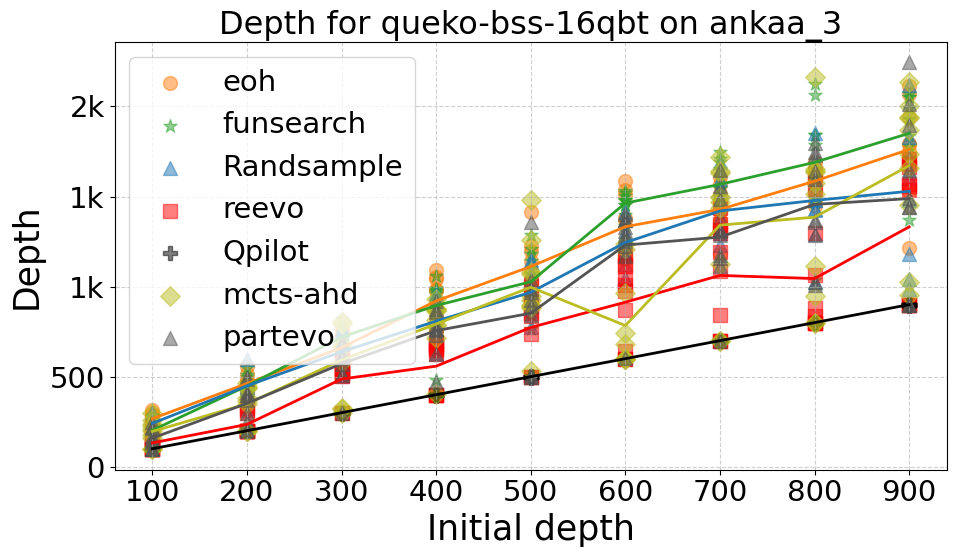

In [19]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/funsearch.csv",
    "Randsample": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/Randsample.csv",
    "reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

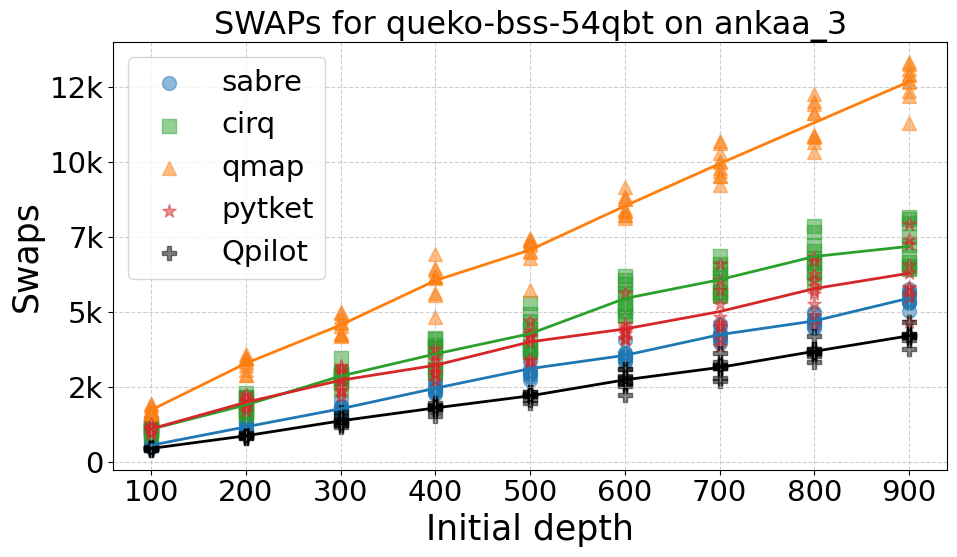

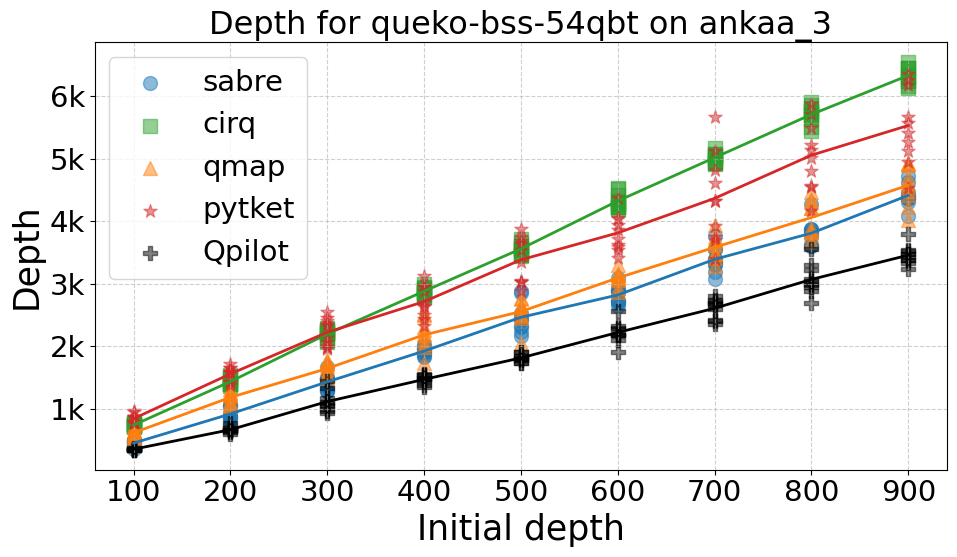

In [15]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

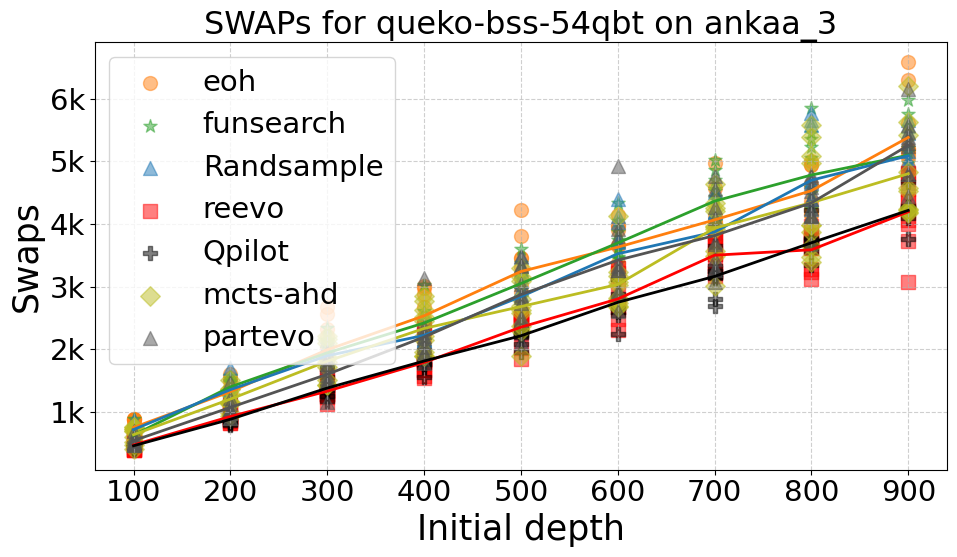

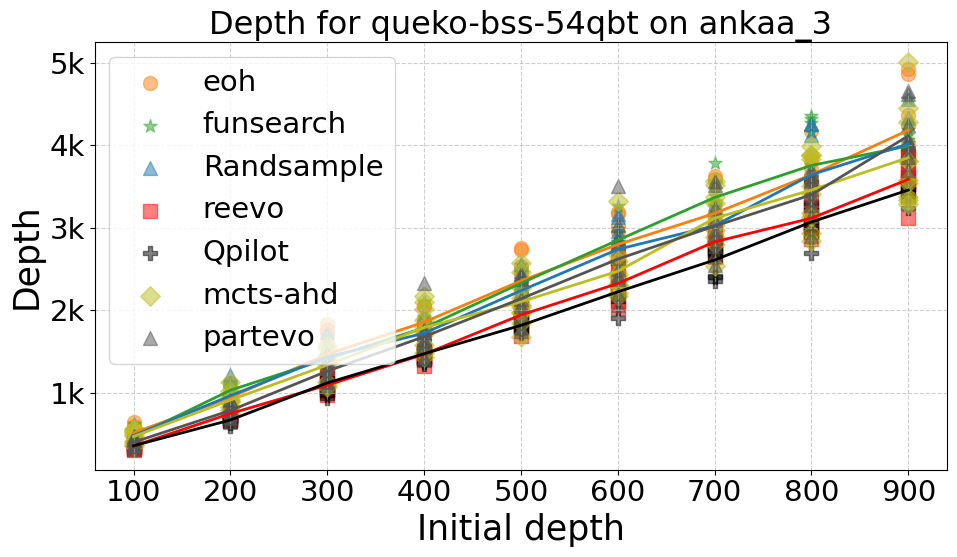

In [16]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/funsearch.csv",
    "Randsample": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/Randsample.csv",
    "reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

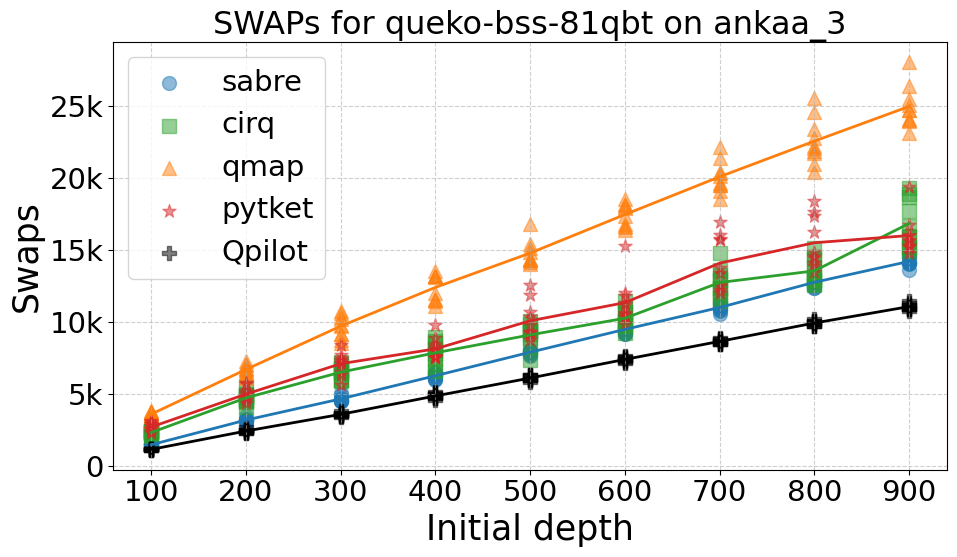

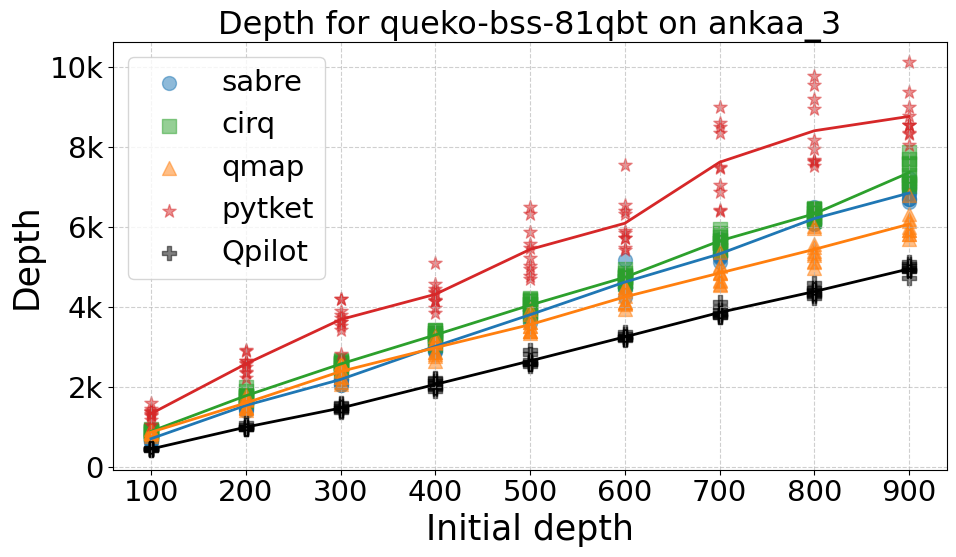

In [1]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "sabre": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/sabre.csv",
    "cirq": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/cirq.csv",
    "qmap": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/qmap.csv",
    "pytket": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/pytket.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/qpilot.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

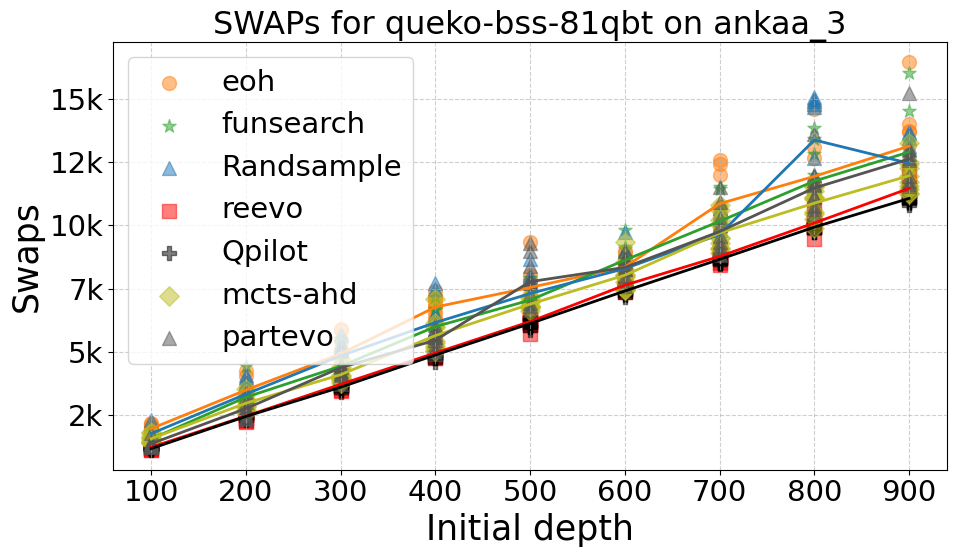

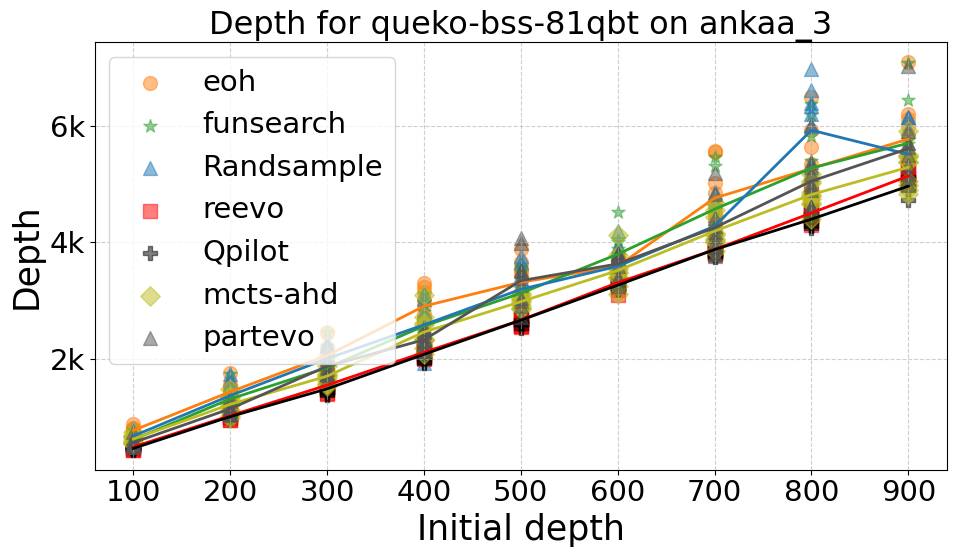

In [23]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "eoh": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/eoh.csv",
    "funsearch": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/funsearch.csv",
    "Randsample": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/Randsample.csv",
    "reevo": f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/reevo.csv",
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/qpilot.csv",
    "mcts-ahd" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/mcts-ahd.csv",
    "partevo" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/partevo.csv"
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

# ablation

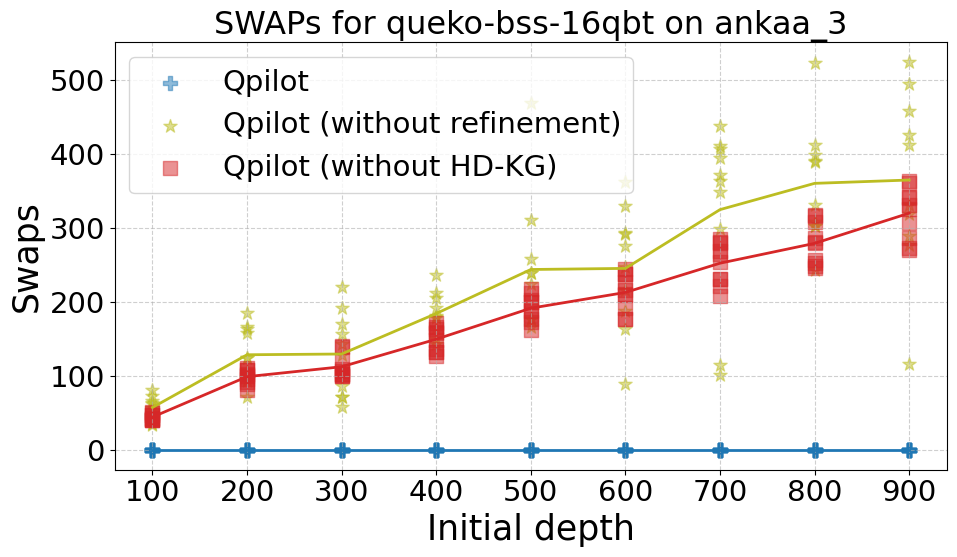

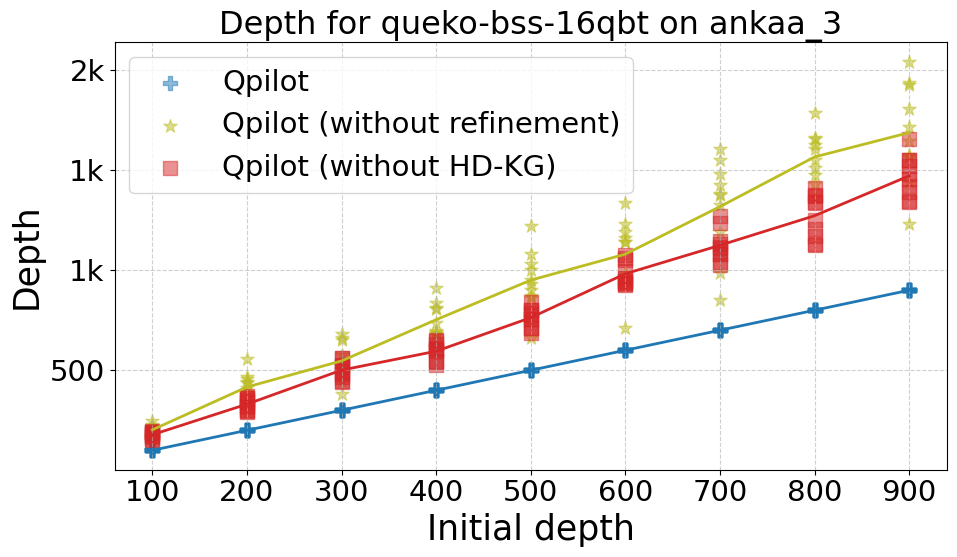

In [1]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-16qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/qpilot.csv",
    "Qpilot (without refinement)" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/new_reevo.csv",
    "Qpilot (without HD-KG)" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-16qbt/new_method.csv",
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

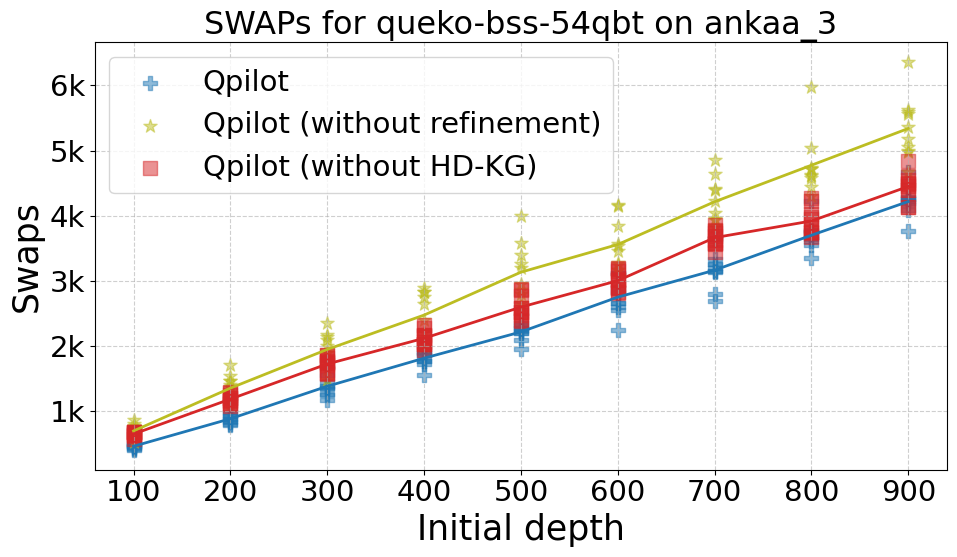

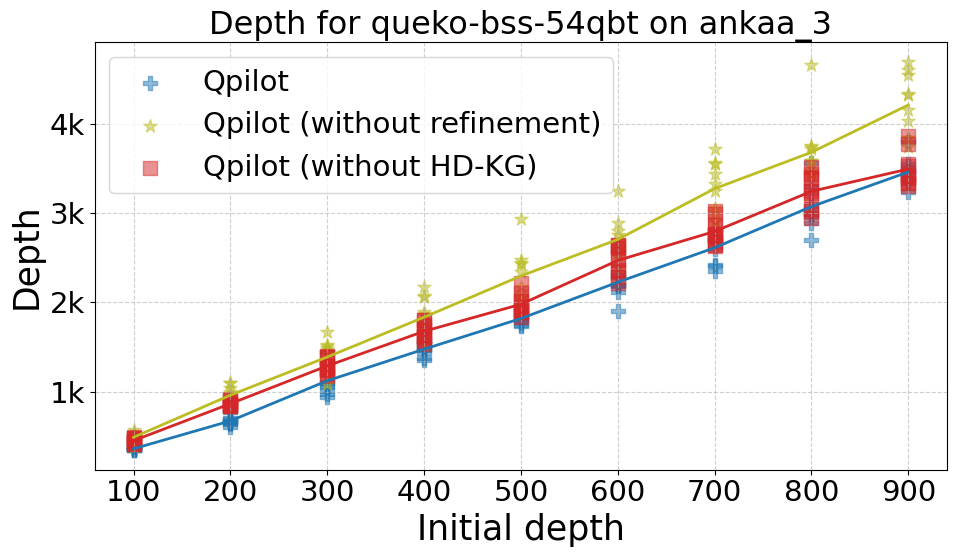

In [2]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-54qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/qpilot.csv",
    "Qpilot (without refinement)" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/new_reevo.csv",
    "Qpilot (without HD-KG)" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-54qbt/new_method.csv",
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

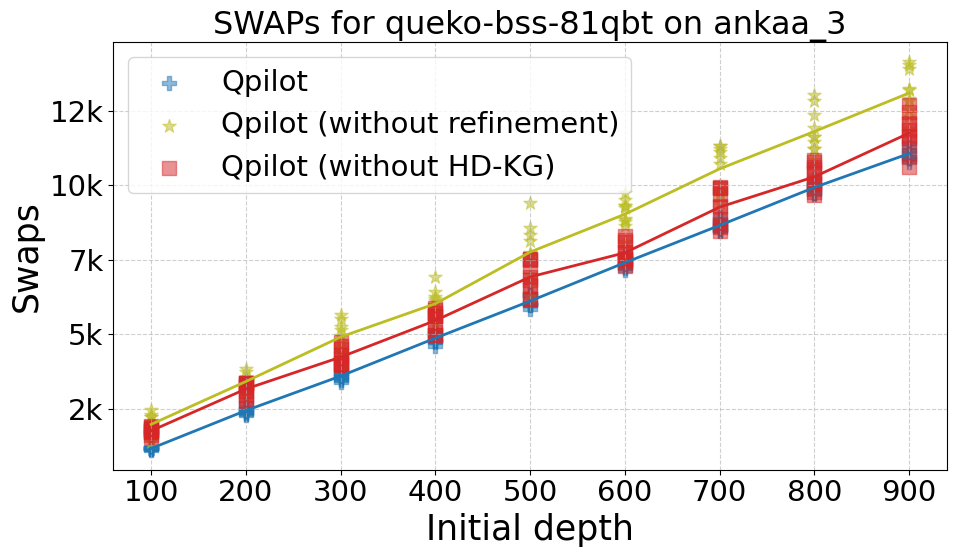

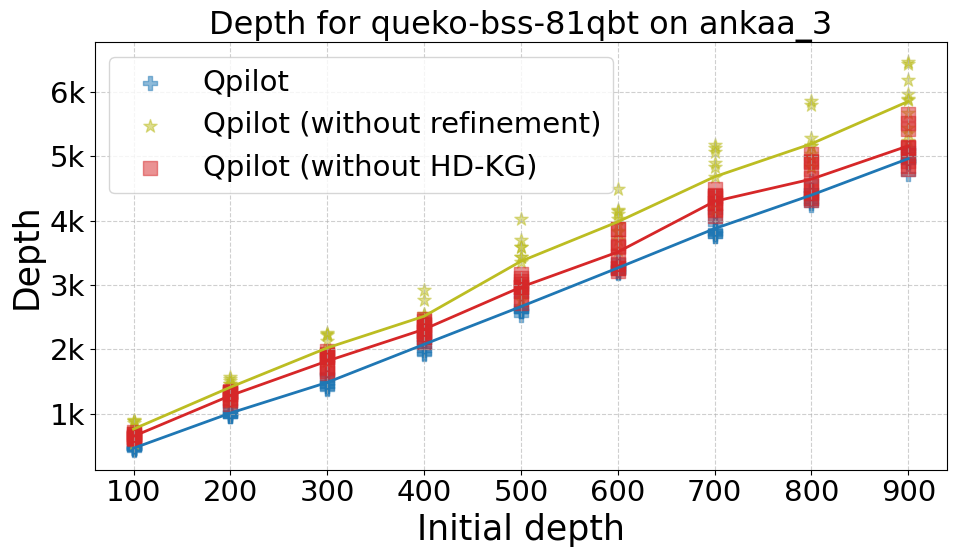

In [3]:
import os
import sys
import matplotlib.pyplot as plt

root_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if root_dir not in sys.path:
    sys.path.append(root_dir)
    
from visualization.utils import (
    group_by_initial_depth, 
    group_by_initial_depth_baseline, 
    plot_grouped_scatter_with_noise
)
BENCHMARK = "queko-bss-81qbt"
BACKEND_NAME = "ankaa_3"

paths = {
    "Qpilot" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/qpilot.csv",
    "Qpilot (without refinement)" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/new_reevo.csv",
    "Qpilot (without HD-KG)" : f"/home/jmsb00nd/Documents/auto-heuristics/experiments_results/ankaa/queko-bss-81qbt/new_method.csv",
}
plot_backend = "sherbrooke" if "sherbrooke" in BACKEND_NAME else "ankaa_3"
figure_idx = 6 if "sherbrooke" in BACKEND_NAME else 7
grouped_data_swaps = {}
grouped_data_depth = {}

for name, path in paths.items():
    if os.path.exists(path):
        swaps, depth = group_by_initial_depth(path)
        grouped_data_swaps[name] = swaps
        grouped_data_depth[name] = depth
    else:
        print(f"Warning: File not found for {name} at {path}")

if grouped_data_swaps:
    plot_grouped_scatter_with_noise(
        grouped_data_swaps, 
        ylabel="Swaps", 
        title=f"SWAPs for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )

if grouped_data_depth:
    plot_grouped_scatter_with_noise(
        grouped_data_depth, 
        ylabel="Depth", 
        title=f"Depth for {BENCHMARK} on {plot_backend}",
        show=True,
        save=False
    )